In [18]:
import joblib             as jlb
import matplotlib.pyplot  as plt
import numpy              as np
import pandas             as pd
import seaborn            as sbn
import warnings
warnings.filterwarnings('ignore') # tắt những cảnh báo

from collections           import Counter
from sklearn.cluster       import DBSCAN
from Dataprepare.data_processing import D

Tiền xử lý dữ liệu

In [19]:
features=[
 'cash_advance',
 'cash_advance_frequency',
 'cash_advance_trx'
]
data=D[features]
print(data.head())
print(data.shape)

   cash_advance  cash_advance_frequency  cash_advance_trx
0     -0.937894               -0.731226         -0.817000
1      1.518315                0.681686          0.768516
2     -0.937894               -0.731226         -0.817000
3     -0.937894               -0.731226         -0.817000
4     -0.937894               -0.731226         -0.817000
(8636, 3)


In [20]:
## Quan sát sơ bộ dữ liệu
print('Shape:', data.shape)
print()
print(data.dtypes)

Shape: (8636, 3)

cash_advance              float64
cash_advance_frequency    float64
cash_advance_trx          float64
dtype: object


In [29]:
##------------------------------------------------------------------------------
## Xây dựng mô hình DBSCAN
##------------------------------------------------------------------------------
## eps        : bán kính lân cận (neighborhood radius)
## min_samples: số điểm tối thiểu trong lân cận để tạo thành core point
##
## Nhãn cluster = -1 → điểm NHIỄU (noise/outlier), không thuộc cụm nào
##------------------------------------------------------------------------------
model = DBSCAN(eps=0.2, min_samples=10)
model.fit(data)  # xây dựng mô hình

,eps,0.2
,min_samples,10
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [30]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(model, '../customer_clustering/Output/DBSCAN.mdl')

['../customer_clustering/Output/DBSCAN.mdl']

In [31]:
## Khai thác mô hình đã được xây dựng
model = jlb.load('../customer_clustering/Output/DBSCAN.mdl')

In [32]:
## Kết quả gom cụm khách hàng
data['cluster'] = model.labels_


n_clusters = len(set(model.labels_)) - (1 if -1 in model.labels_ else 0)
n_noise    = list(model.labels_).count(-1)

print(f'\nSố clusters tìm được  : {n_clusters}')
print(f'Số điểm nhiễu (noise): {n_noise}')
print('\nKích thước các clusters (bao gồm noise = -1):', Counter(model.labels_))


Số clusters tìm được  : 7
Số điểm nhiễu (noise): 280

Kích thước các clusters (bao gồm noise = -1): Counter({np.int64(0): 4431, np.int64(1): 2069, np.int64(2): 830, np.int64(4): 579, np.int64(3): 414, np.int64(-1): 280, np.int64(5): 23, np.int64(6): 10})


Biểu diễn trực quan

In [33]:
data['cluster'] = model.labels_
print(data.head())

   cash_advance  cash_advance_frequency  cash_advance_trx  cluster
0     -0.937894               -0.731226         -0.817000        0
1      1.518315                0.681686          0.768516        1
2     -0.937894               -0.731226         -0.817000        0
3     -0.937894               -0.731226         -0.817000        0
4     -0.937894               -0.731226         -0.817000        0


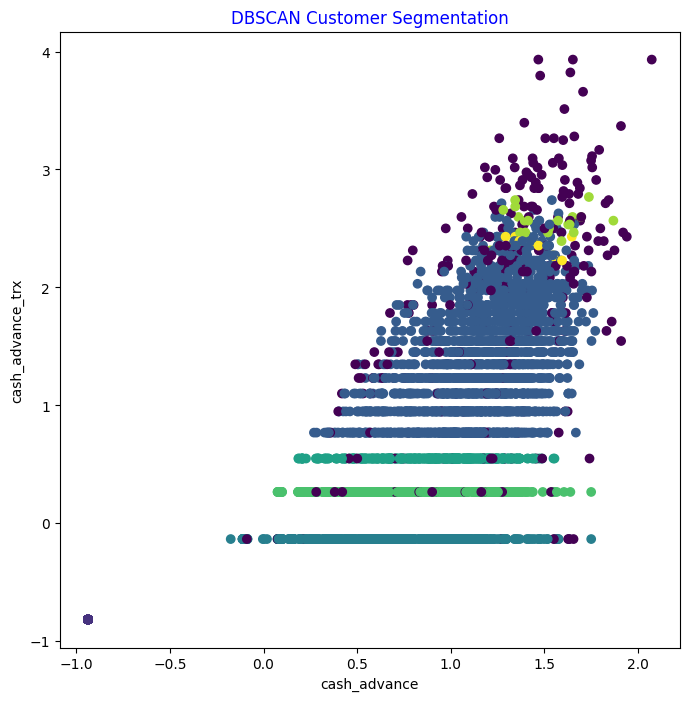

In [34]:
plt.figure(figsize=(8,8))

plt.scatter(
    data.cash_advance,
    data['cash_advance_trx'],
    c=data.cluster
)

plt.xlabel("cash_advance")
plt.ylabel("cash_advance_trx")
plt.title("DBSCAN Customer Segmentation", color="blue")

plt.show()